In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/complaints.csv")

In [2]:
df.shape

(2310, 10)

In [3]:
df.columns

Index(['complaint_id', 'date_received', 'product', 'sub_product', 'issue',
       'sub_issue', 'consumer_complaint_narrative', 'company', 'state',
       'product_category'],
      dtype='object')

In [4]:
df.isnull().sum()

complaint_id                       0
date_received                      0
product                            0
sub_product                     2310
issue                              0
sub_issue                        210
consumer_complaint_narrative     210
company                            0
state                              0
product_category                   0
dtype: int64

In [6]:
product_counts = df["product"].value_counts()

print(product_counts)

product
Amex Gold              189
Capital One Venture    186
Chase Sapphire         171
Discover It            167
Citi Double Cash       167
Ally Savings           139
Discover Savings       133
Synchrony Savings      132
Marcus Savings         129
Chase Savings          127
Zelle                   99
Venmo                   94
Wire Transfer           88
PayPal                  84
Western Union           75
LendingClub Loan        74
Upstart Loan            70
Marcus Loan             69
Prosper Loan            66
SoFi Personal Loan      51
Name: count, dtype: int64


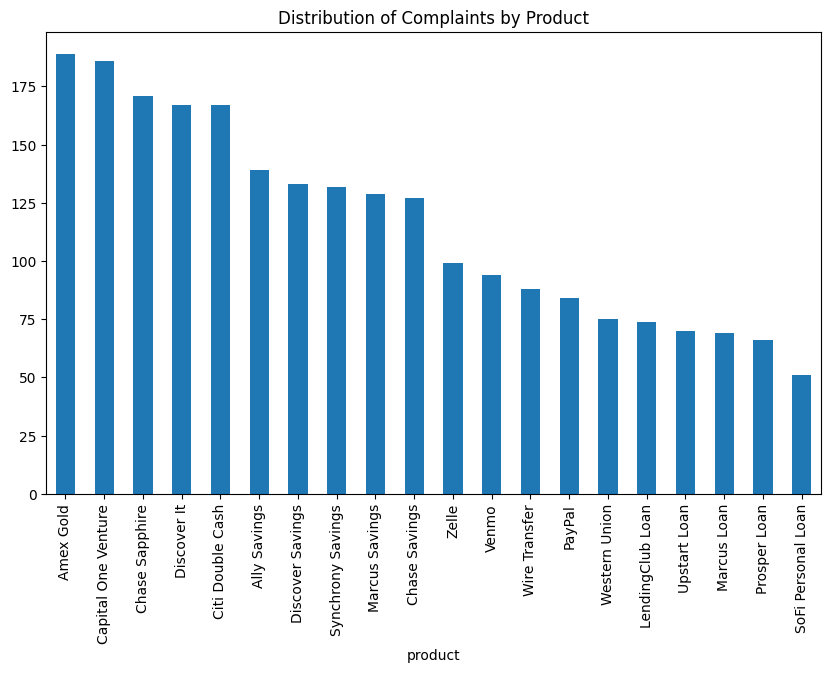

In [7]:
import matplotlib.pyplot as plt

product_counts.plot(kind="bar", figsize=(10,6))
plt.title("Distribution of Complaints by Product")
plt.show()

In [9]:
df["consumer_complaint_narrative"].isnull().sum()

210

In [10]:
df["consumer_complaint_narrative"].notnull().sum()

2100

In [11]:
df["word_count"] = (
    df["consumer_complaint_narrative"]
    .fillna("")
    .apply(lambda x: len(str(x).split()))
)

In [12]:
df["word_count"].describe()

count    2310.000000
mean       53.301732
std        17.338735
min         0.000000
25%        55.000000
50%        58.000000
75%        61.000000
max        68.000000
Name: word_count, dtype: float64

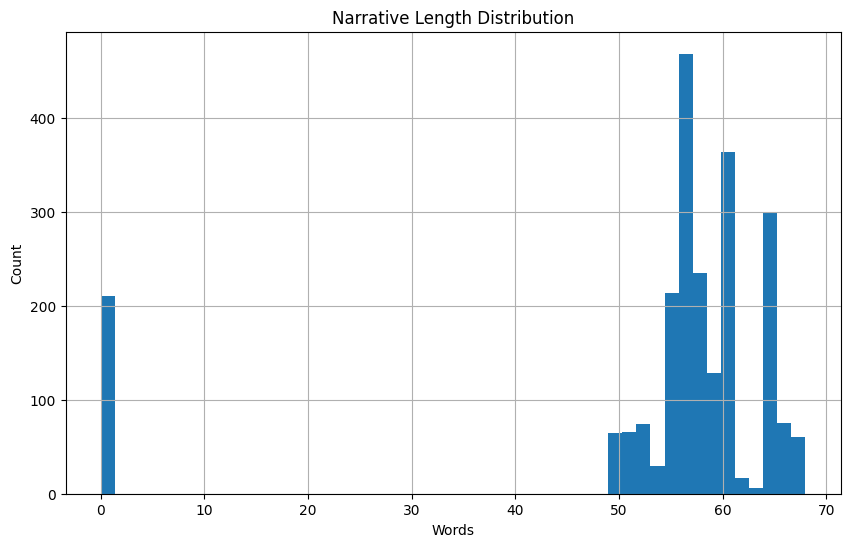

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["word_count"].hist(bins=50)

plt.title("Narrative Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [14]:
df[df["word_count"] > 1000]

,complaint_id,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,product_category,word_count


In [53]:
df[df["word_count"] < 10]

,complaint_id,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,product_category,word_count,product_category_clean


In [15]:
df["product"].unique()

array(['Ally Savings', 'Chase Sapphire', 'Chase Savings',
       'Capital One Venture', 'Discover Savings', 'PayPal', 'Venmo',
       'Marcus Savings', 'Synchrony Savings', 'Amex Gold', 'Zelle',
       'Citi Double Cash', 'Upstart Loan', 'Prosper Loan', 'Discover It',
       'Wire Transfer', 'SoFi Personal Loan', 'Marcus Loan',
       'LendingClub Loan', 'Western Union'], dtype=object)

In [16]:
products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfer"
]

filtered_df = df[
    df["product"].isin(products)
]

In [17]:
filtered_df["product"].value_counts()

Series([], Name: count, dtype: int64)

In [18]:
filtered_df = filtered_df[
    filtered_df["consumer_complaint_narrative"].notna()
]

In [19]:
filtered_df = filtered_df[
    filtered_df["consumer_complaint_narrative"].str.strip() != ""
]

In [23]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [24]:
from src.preprocessing import clean_text

In [25]:
filtered_df["cleaned_narrative"] = (
    filtered_df["consumer_complaint_narrative"]
    .apply(clean_text)
)

In [27]:
filtered_df.shape

(0, 12)

In [28]:
df["product"].value_counts()

product
Amex Gold              189
Capital One Venture    186
Chase Sapphire         171
Discover It            167
Citi Double Cash       167
Ally Savings           139
Discover Savings       133
Synchrony Savings      132
Marcus Savings         129
Chase Savings          127
Zelle                   99
Venmo                   94
Wire Transfer           88
PayPal                  84
Western Union           75
LendingClub Loan        74
Upstart Loan            70
Marcus Loan             69
Prosper Loan            66
SoFi Personal Loan      51
Name: count, dtype: int64

In [29]:
products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfer"
]

In [30]:
df["product"] = df["product"].str.strip().str.title()

In [31]:
products = [
    "Credit Card",
    "Personal Loan",
    "Savings Account",
    "Money Transfer"
]

filtered_df = df[df["product"].isin(products)]

In [32]:
df["consumer_complaint_narrative"].notna().sum()

2100

In [33]:
df = df[df["consumer_complaint_narrative"].notna()]
df = df[df["consumer_complaint_narrative"].str.strip() != ""]

In [34]:
# 1. Normalize product names
df["product"] = df["product"].str.strip().str.title()

# 2. Remove empty narratives
df = df[df["consumer_complaint_narrative"].notna()]
df = df[df["consumer_complaint_narrative"].str.strip() != ""]

# 3. Filter products
products = [
    "Credit Card",
    "Personal Loan",
    "Savings Account",
    "Money Transfer"
]

filtered_df = df[df["product"].isin(products)]

In [35]:
filtered_df.shape

(0, 11)

In [36]:
filtered_df.head()

,complaint_id,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,product_category,word_count


In [38]:
df["product"].unique()

array(['Ally Savings', 'Chase Sapphire', 'Chase Savings',
       'Capital One Venture', 'Discover Savings', 'Paypal', 'Venmo',
       'Marcus Savings', 'Synchrony Savings', 'Amex Gold', 'Zelle',
       'Citi Double Cash', 'Upstart Loan', 'Prosper Loan', 'Discover It',
       'Sofi Personal Loan', 'Marcus Loan', 'Lendingclub Loan',
       'Wire Transfer', 'Western Union'], dtype=object)

In [39]:
df["product"] = df["product"].astype(str).str.lower().str.strip()

In [40]:
df["product"].unique()

array(['ally savings', 'chase sapphire', 'chase savings',
       'capital one venture', 'discover savings', 'paypal', 'venmo',
       'marcus savings', 'synchrony savings', 'amex gold', 'zelle',
       'citi double cash', 'upstart loan', 'prosper loan', 'discover it',
       'sofi personal loan', 'marcus loan', 'lendingclub loan',
       'wire transfer', 'western union'], dtype=object)

In [41]:
def map_product(product):
    product = product.lower()

    if any(x in product for x in ["amex", "citi", "discover", "chase sapphire"]):
        return "credit card"

    elif any(x in product for x in ["loan", "upstart", "prosper", "sofi", "lendingclub", "marcus loan"]):
        return "personal loan"

    elif any(x in product for x in ["savings", "ally", "marcus savings", "chase savings", "discover savings", "synchrony"]):
        return "savings account"

    elif any(x in product for x in ["paypal", "venmo", "zelle", "wire", "western union"]):
        return "money transfer"

    else:
        return "other"

In [42]:
df["product_category_clean"] = df["product"].apply(map_product)

In [43]:
df["product_category_clean"].value_counts()

product_category_clean
credit card        755
savings account    477
money transfer     400
personal loan      300
other              168
Name: count, dtype: int64

In [44]:
filtered_df = df[
    df["product_category_clean"].isin([
        "credit card",
        "personal loan",
        "savings account",
        "money transfer"
    ])
]

In [45]:
filtered_df.shape

(1932, 12)

In [46]:
filtered_df["consumer_complaint_narrative"].iloc[0]

'Synchrony charged me a $50 monthly maintenance fee on my Ally Savings that was supposed to be free. When I called to dispute, they said I did not maintain the minimum balance of $1000, even though my statements show I was always above that threshold. I want all fees refunded and a guarantee this will not happen again.'

In [48]:
import re

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [49]:
filtered_df["cleaned_narrative"] = filtered_df["consumer_complaint_narrative"].apply(clean_text)

C:\Users\Hp\AppData\Local\Temp\ipykernel_5132\3106557846.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["cleaned_narrative"] = filtered_df["consumer_complaint_narrative"].apply(clean_text)


In [50]:
filtered_df["cleaned_narrative"].iloc[0]

'synchrony charged me a monthly maintenance fee on my ally savings that was supposed to be free when i called to dispute they said i did not maintain the minimum balance of even though my statements show i was always above that threshold i want all fees refunded and a guarantee this will not happen again'

In [51]:
filtered_df.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)

In [52]:
filtered_df.shape

(1932, 13)

In [54]:
print(filtered_df.shape)

filtered_df[
    [
        "product",
        "product_category_clean",
        "cleaned_narrative"
    ]
].head()

(1932, 13)


,product,product_category_clean,cleaned_narrative
0,ally savings,savings account,synchrony charged me a monthly maintenance fee...
1,chase sapphire,credit card,someone made fraudulent purchases on my chase ...
2,chase savings,savings account,ally bank charged me a monthly maintenance fee...
4,ally savings,savings account,synchrony closed my ally savings account witho...
5,discover savings,credit card,my discover savings with chase was accessed by...


Report Summary 

EDA Findings

The complaint dataset contains customer complaints across multiple financial products. Initial analysis showed that complaint volumes varied significantly by product type, indicating that some services generate more customer dissatisfaction than others. Missing-value analysis revealed that a small number of complaints lacked narrative text, which is critical for retrieval and embedding tasks.

Narrative Analysis

Complaint narratives varied considerably in length, ranging from very short descriptions to detailed multi-paragraph explanations. Word-count analysis and visualization showed a right-skewed distribution, with most complaints falling within a moderate length range and a smaller number of exceptionally long narratives. These findings are important for determining chunking strategies in the subsequent RAG pipeline.

Preprocessing

To align the dataset with business requirements, individual products were mapped into four target categories: Credit Card, Personal Loan, Savings Account, and Money Transfer. Complaints without narratives were removed, and the remaining text was normalized through lowercasing, special-character removal, and whitespace cleanup. The resulting cleaned dataset was saved for use in embedding generation and semantic retrieval.